# BEAVERS: Attributes from static maps
***

**_Autor:_** Chus Casado Rodríguez<br>
**_Fecha:_** 15-05-2026<br>

**Introduction:**<br>
This notebook creates the static attributes related to EFAS static maps.

**Ideas:**<br>

In [1]:
from tqdm.auto import tqdm
from typing import List
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd

from reservoirs_lshm.utils.plots import plot_attributes

from ocab.config import Config
from ocab.basins.stats import read_pixarea, basin_statistics, read_input_maps

## Configuration

In [2]:
cfg = Config('config_BEAVERS_v100.yml')

# output folders
path_attrs = cfg.path_dataset / 'attributes'
path_plots = cfg.path_plots / 'attributes'
for path in [path_attrs, path_plots]:
    path.mkdir(parents=False, exist_ok=True)
print(f'Attribute tables will be saved in {path_attrs}')

Attribute tables will be saved in /home/casadoj/Data/BEAVERS-ES/v1_0_0/attributes


## Ancillary Data

In [3]:
# load basin outlets
outlets = gpd.read_file(cfg.path_gis / 'dams.geojson').set_index('id')
print(f'{len(outlets)} basin outlets')

# load basin polygons
basins = gpd.read_file(cfg.path_dataset / 'preprocessing' / 'basins' / 'output' / 'dams_basins_3sec.geojson')
basins.columns = basins.columns.str.lower()
basins.set_index('id', inplace=True)
print(f'{len(outlets)} basin polygons')

# load pixel area and upstream area maps
pixarea = read_pixarea(next((cfg.path_efas / 'maps').glob('pixarea*.nc')), crs=cfg.crs)
uparea = read_pixarea(next((cfg.path_efas / 'maps').glob('upArea*.nc')), crs=cfg.crs)

# extract extent
extent = pixarea.rio.bounds()
extent = [extent[0], extent[2], extent[1], extent[3]]

374 basin outlets
374 basin polygons


## LISFLOOD static maps

In this section I will compute catchment statistics of the LISFLOOD static maps that will be in the end exported as _glofas_static_maps.csv_. As ancillary maps, I have loaded first the pixel area and upstream area maps, that will be needed in the subsequent calculations.

In [4]:
# list where attributes will be appended
attributes = []

### Geomorphology

basins:   0%|          | 0/374 [00:00<?, ?it/s]

2026-05-15 14:03:21,302 | INFO | ocab.basins.stats.main | Time elapsed: 19.04 seconds


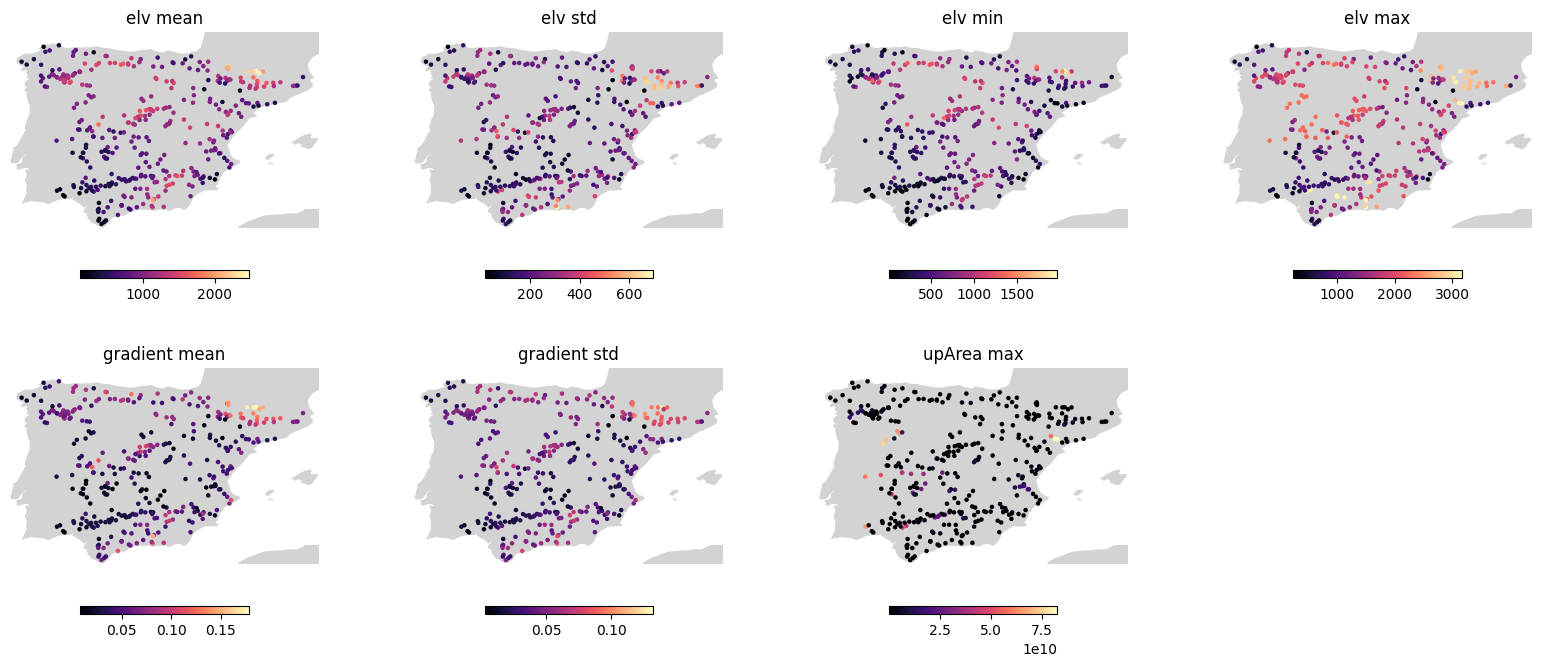

In [5]:
func = {
    'elv': ['mean', 'std', 'min', 'max'],
    'gradient': ['mean', 'std'],
    'upArea': ['max'],
    # 'pixarea': ['sum']
}

# load maps
geomorphology = read_input_maps(
    path=cfg.path_efas / 'maps',
    variables=func.keys(),
    crs=cfg.crs
)

# compute statistics
statistic = list(np.unique([stat for stats in func.values() for stat in stats]))
attr_geomorphology = basin_statistics(
    geomorphology, 
    basins, 
    statistic=statistic, 
    weight=pixarea
).to_pandas()
cols = [f'{var}_{stat}' for var, stats in func.items() for stat in stats]
attr_geomorphology = attr_geomorphology[cols]

# plot attributes
plot_attributes(
    attr_geomorphology, 
    outlets.geometry.x, 
    outlets.geometry.y, 
    save=path_plots / 'maps_geomorphology.jpg',
    ncols=4, 
    extent=extent
)

# save
attributes.append(attr_geomorphology)

### Land use

basins:   0%|          | 0/374 [00:00<?, ?it/s]

2026-05-15 14:03:48,867 | INFO | ocab.basins.stats.main | Time elapsed: 24.63 seconds


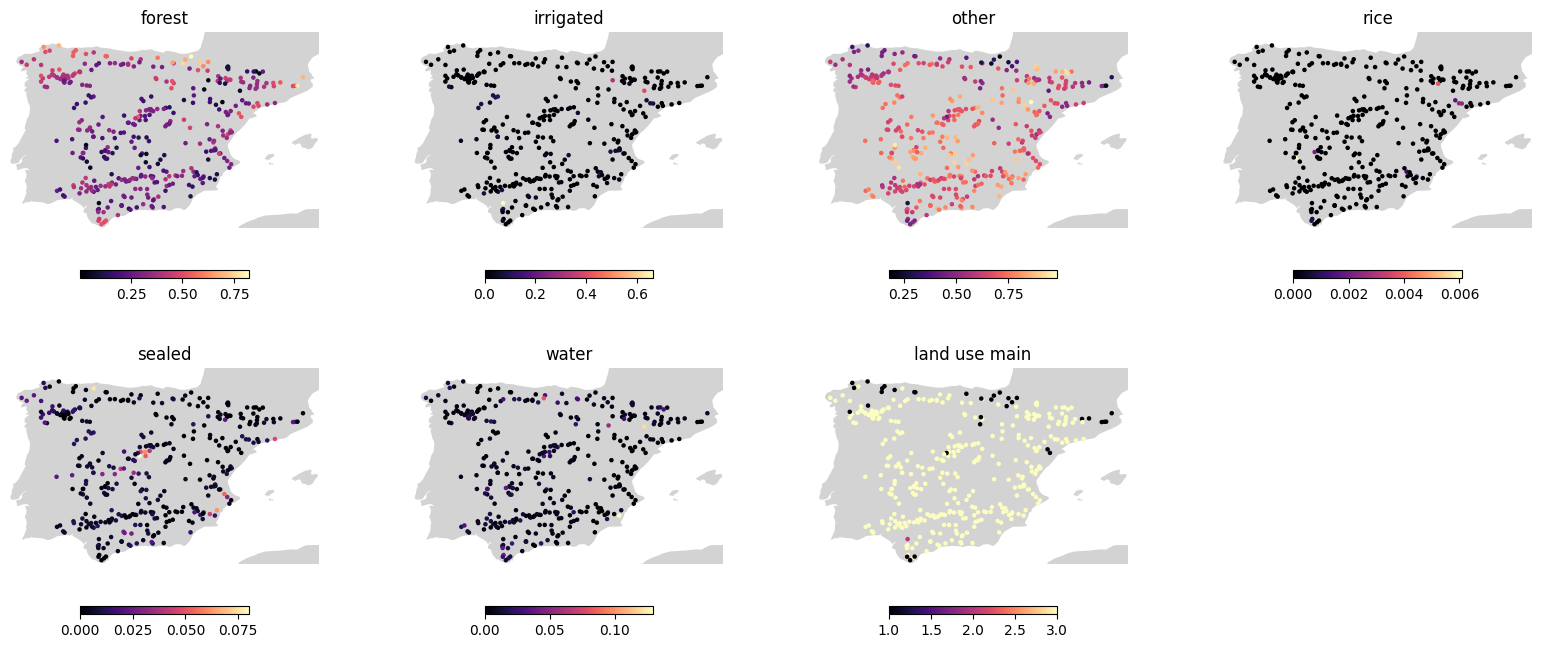

In [6]:
variables = ['fracforest', 'fracirrigated', 'fracother', 'fracrice', 'fracwater', 'fracsealed']
variables.sort()

# load maps
land_use  = read_input_maps(
    path=cfg.path_efas / 'maps',
    variables=variables,
    crs=cfg.crs
)
land_use = land_use.rename({var: var[4:] for var in list(land_use)})
# land_use = land_use.sel(extent_dct)

# compute statistics
attr_landuse = basin_statistics(
    land_use, 
    basins, 
    statistic=['mean'], 
    weight=pixarea
).to_pandas()
cols = [f'{var[4:]}_mean' for var in variables]
attr_landuse = attr_landuse[cols]
attr_landuse.sort_index(axis=1, inplace=True)

# compute main land use
lu_classes = {col: i for i, col in enumerate(attr_landuse.columns, start=1)}
attr_landuse['land_use_main'] = attr_landuse.idxmax(axis=1).map(lu_classes)

# rename attributes
attr_landuse.rename(columns={col: col.split('_')[0] if 'mean' in col else col for col in attr_landuse}, inplace=True)
attr_landuse.rename(columns={col: 'frac' + col.split('_')[0] if 'mean' in col else col for col in attr_landuse}, inplace=True)

# plot attributes
plot_attributes(
    attr_landuse, 
    outlets.geometry.x, 
    outlets.geometry.y, 
    save=path_plots / 'maps_landuse.jpg',
    ncols=4,
    extent=extent
)

# save
attributes.append(attr_landuse)

### Crop coefficient

basins:   0%|          | 0/374 [00:00<?, ?it/s]

2026-05-15 14:03:57,981 | INFO | ocab.basins.stats.main | Time elapsed: 8.16 seconds


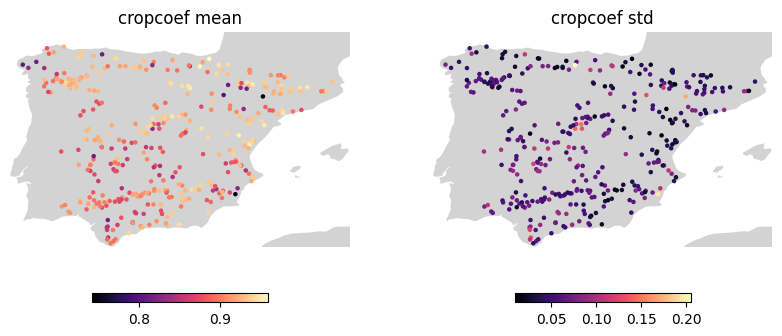

In [7]:
# mapping land use acronym and name
mapping_landuse = {'f': 'forest', 'i': 'irrigated', 'o': 'other'}
variables = ['cropcoef_f', 'cropcoef_i', 'cropcoef_o']
stats = ['mean', 'std']

# load maps
crops = read_input_maps(
    path=cfg.path_efas / 'maps',
    variables=variables,
    crs=cfg.crs
)
crops = crops.rename({var: mapping_landuse[var.split('_')[1]] for var in list(crops)})

# mean weighted by the fraction of pixel covered by each land use
crops = crops.to_array('land_use').weighted(land_use.to_array('land_use').fillna(0)).sum('land_use', skipna=True) 
crops = crops.where(uparea.notnull())
crops.name = 'cropcoef'
crops = crops.to_dataset().rio.write_crs(cfg.crs)

# compute statistics
attr_crops = basin_statistics(
    crops,
    basins, 
    statistic=stats, 
    weight=pixarea
).to_pandas()

# columns to keep
cols = [col for col in attr_crops.columns if any(stat in col for stat in stats)]
attr_crops = attr_crops[cols]

# plot attributes
plot_attributes(
    attr_crops, 
    outlets.geometry.x, 
    outlets.geometry.y, 
    save=path_plots / 'maps_crops.jpg',
    ncols=2,
    extent=extent
)

# save
attributes.append(attr_crops)

### Streams

basins:   0%|          | 0/374 [00:00<?, ?it/s]

2026-05-15 14:04:37,969 | INFO | ocab.basins.stats.main | Time elapsed: 37.71 seconds


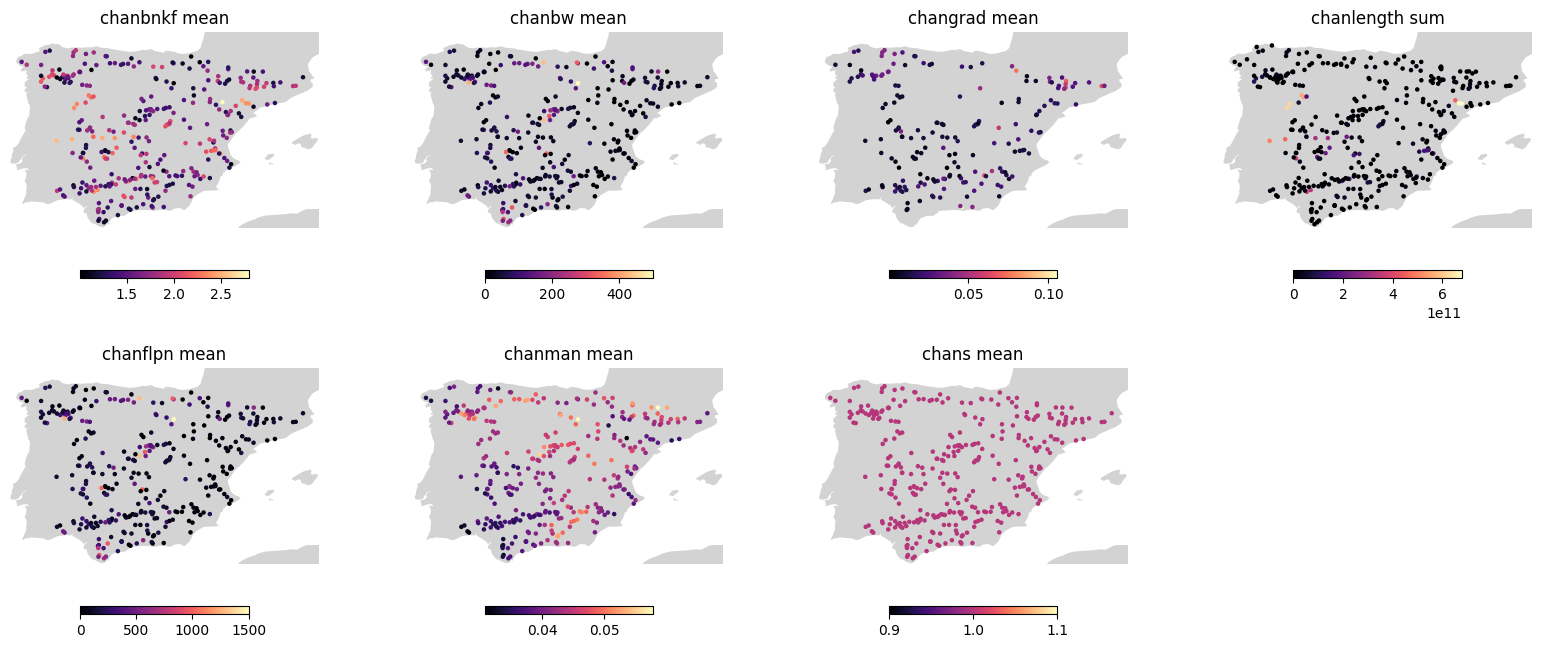

In [8]:
func = {
    'chanbnkf': ['mean'],
    'chanbw': ['mean'],
    'changrad': ['mean'],
    'chanlength': ['sum'],
    'chanflpn': ['mean'],
    'chanman': ['mean'],
    'chans': ['mean'],
}

# load maps
streams = read_input_maps(
    cfg.path_efas / 'maps',
    variables=func.keys(),
    crs=cfg.crs
)

# mask streams (pixels with depth larger than 1 m)
rivers = streams['chanbnkf'] > 1
# rivers.plot(cmap='Blues')
streams = streams.where(rivers)
streams = streams.rio.write_crs(cfg.crs)


# calcular estadístico
statistic = list(np.unique([stat for stats in func.values() for stat in stats]))
attr_streams = basin_statistics(
    streams, 
    basins, 
    statistic, 
    weight=pixarea
).to_pandas()
cols = [f'{var}_{stat}' for var, stats in func.items() for stat in stats]
attr_streams = attr_streams[cols]

# plot attributes
plot_attributes(
    attr_streams,
    outlets.geometry.x, 
    outlets.geometry.y, 
    save=path_plots / 'maps_streams.jpg',
    ncols=4,
    extent=extent
)

# save
attributes.append(attr_streams)

### Soil properties

loading maps:   0%|          | 0/18 [00:00<?, ?it/s]

basins:   0%|          | 0/374 [00:00<?, ?it/s]

2026-05-15 14:05:53,442 | INFO | ocab.basins.stats.main | Time elapsed: 70.82 seconds


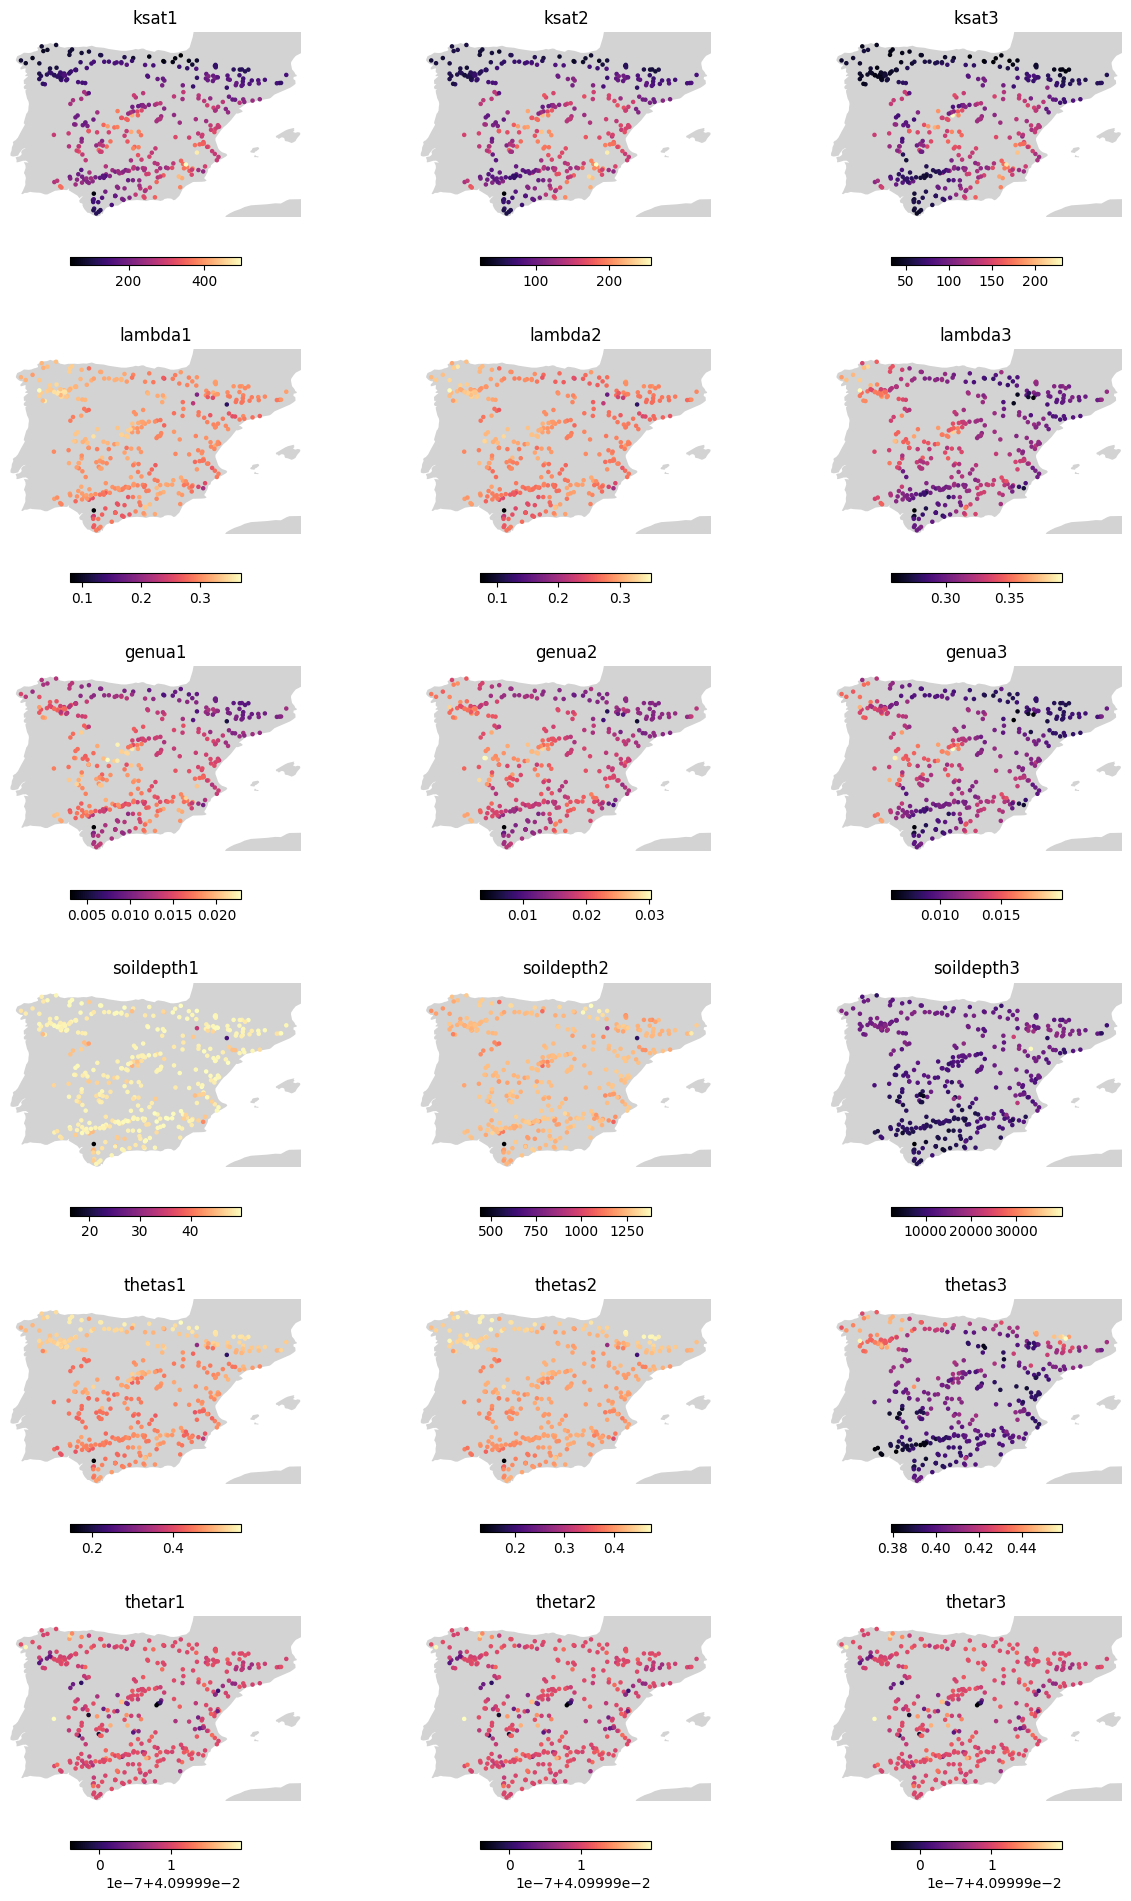

In [9]:
variables = ['ksat', 'lambda', 'genua', 'soildepth', 'thetas', 'thetar']
layers = [1, 2, 3]
variables = [f'{var}{layer}' for var in variables for layer in layers]

# load maps
soils = {}
for var in tqdm(variables, desc='loading maps'):
    files = list((cfg.path_efas / 'maps').glob(f'{var}_*.nc'))
    if len(files) > 1:
        ds = {}
        for file in files:
            # type of land use
            cover = mapping_landuse[file.stem.split('_')[1]]
            # import map
            ds[cover] = xr.open_dataset(file)['Band1']
        ds = xr.Dataset(ds)
        da = ds.to_array('land_use').weighted(land_use.to_array('land_use').fillna(0)).sum('land_use', skipna=True)
        soils[var] = da.where(uparea.notnull())
    elif len(files) == 1:
        soils[var] = xr.open_dataset(files[0])['Band1']
soils = xr.Dataset(soils).rio.write_crs(cfg.crs)

# compute statistics
attr_soils = basin_statistics(
    soils, 
    basins, 
    statistic=['mean'], 
    weight=pixarea
).to_pandas()

# rename attributes
rename_cols = {col: col.split('_')[0] for col in attr_soils if 'mean' in col}
attr_soils = attr_soils[rename_cols.keys()].rename(columns=rename_cols)


# plot attributes
plot_attributes(
    attr_soils, 
    outlets.geometry.x, 
    outlets.geometry.y, 
    save=path_plots / 'maps_soils.jpg',
    ncols=3,
    extent=extent
)

# save
attributes.append(attr_soils)

### LAI

I convert the timeseries of 10-daily timesteps into annual and monthly averages.

basins:   0%|          | 0/374 [00:00<?, ?it/s]

2026-05-15 14:06:54,421 | INFO | ocab.basins.stats.main | Time elapsed: 54.88 seconds


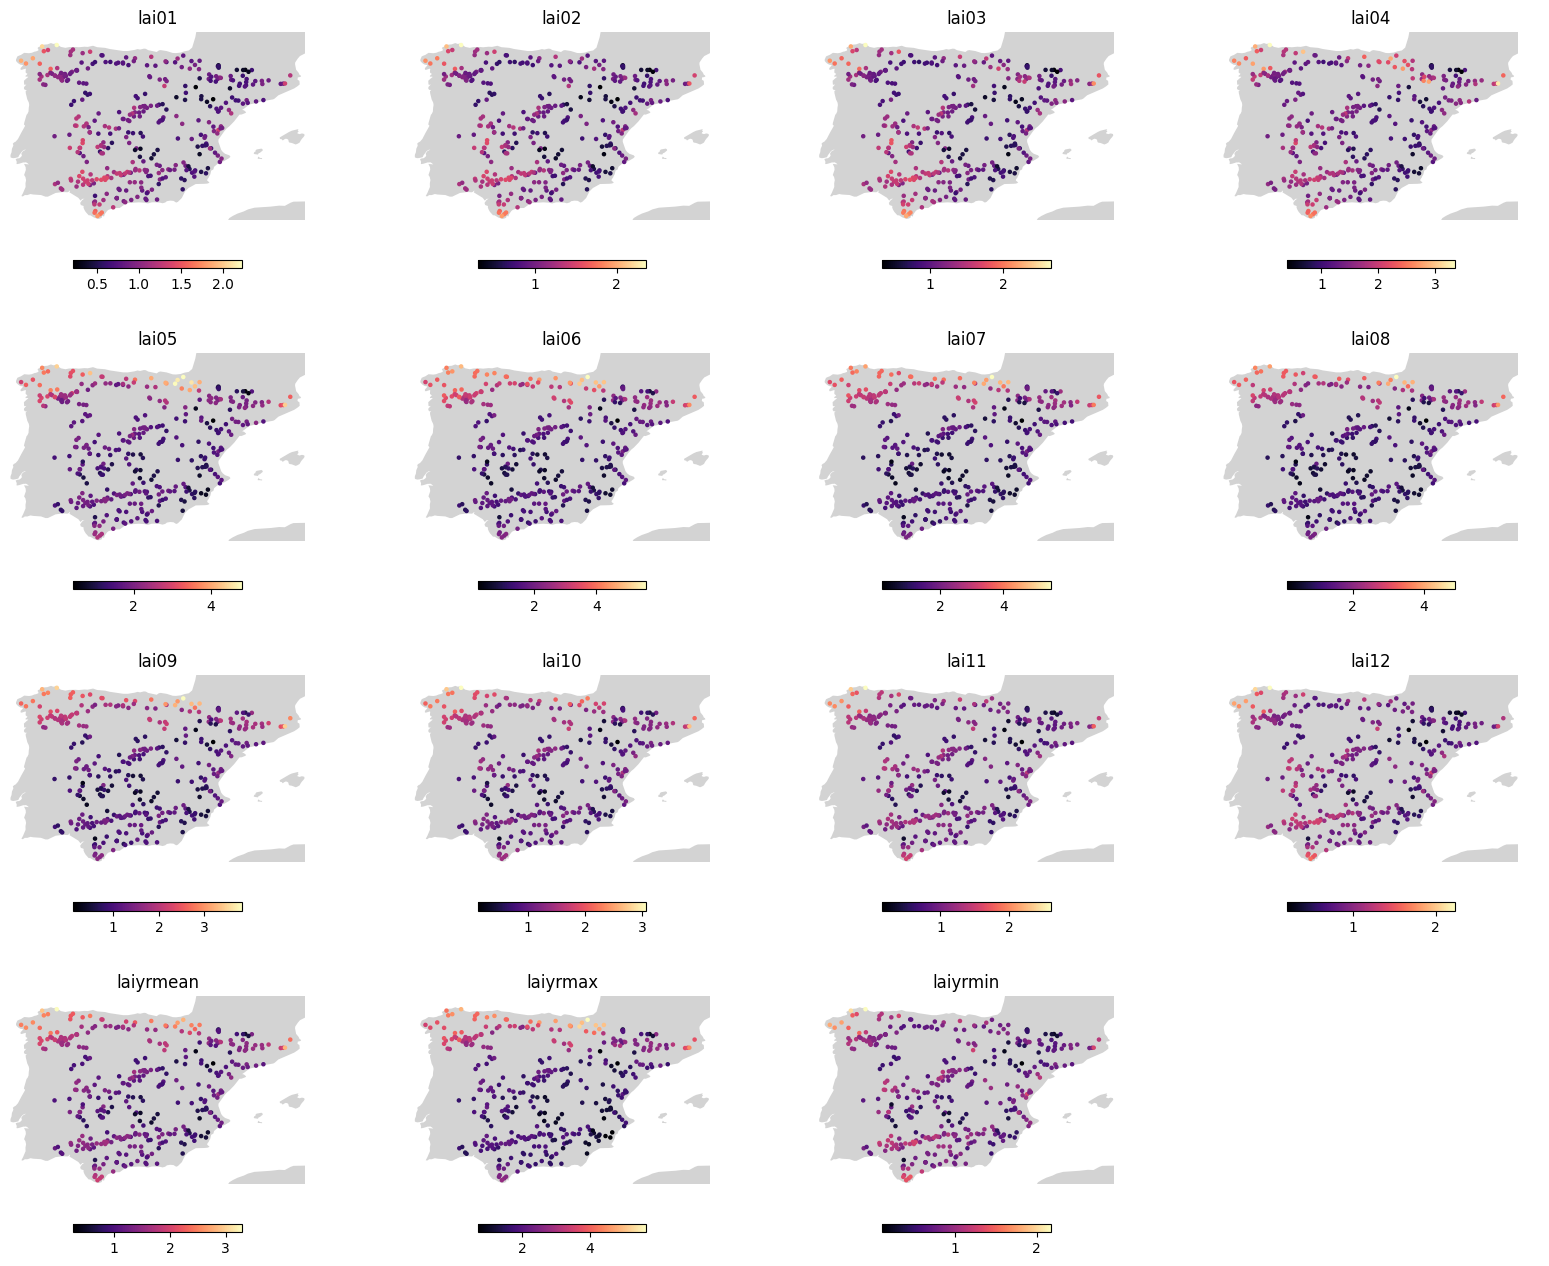

In [10]:
variables = ['laif', 'laii', 'laio']

# load maps
# lai = xr.Dataset({var: xr.open_mfdataset(f'{cfg.path_efas}/static_maps/{var}*.nc')['Band1'] for var in variables})
lai = read_input_maps(cfg.path_efas / 'maps', variables=variables, crs=cfg.crs)
lai = lai.rename({var: mapping_landuse[var[3]] for var in list(lai)})
# lai = lai.sel(extent_dct).compute()

# mean weighted by the portion of pixel covered by each land use
lai = lai.to_array('land_use').weighted(land_use.to_array('land_use').fillna(0)).sum('land_use', skipna=True) 
lai = lai.where(uparea.notnull())
lai.name = 'lai'
lai['time'] = pd.date_range('2021-01-05', periods=len(lai.time), freq='10D')

# monthly resampling
lai_m = lai.resample(time='MS').mean()
lai_m['time'] = [f'{i:02}' for i in range(1, 13)]
lai_agg = xr.Dataset({f'lai{month}': lai_m.sel(time=month).drop_vars('time') for month in lai_m.time.data})

# annual statistics
lai_agg['laiyrmean'] = lai.mean('time')
lai_agg['laiyrmax'] = lai.max('time')
lai_agg['laiyrmin'] = lai.min('time')
lai_agg = lai_agg.rio.write_crs(cfg.crs)

# compute statistics
attr_lai = basin_statistics(
    lai_agg,
    basins, 
    statistic=['mean'], 
    weight=pixarea
).to_pandas()

# rename attributes
rename_cols = {col: '_'.join(col.split('_')[:-1]) for col in attr_lai if 'mean' in col}
attr_lai = attr_lai[rename_cols.keys()].rename(columns=rename_cols)

# plot attributes
plot_attributes(
    attr_lai, 
    outlets.geometry.x, 
    outlets.geometry.y, 
    save=path_plots / 'maps_lai.jpg',
    ncols=4,
    extent=extent
)

# save
attributes.append(attr_lai)

### Water demand

The original demand maps are monthly time series (domestic, energy, industry, livestock) in mm/day for the period 1990-2023. 

I will compute annual and monthly averages and from those I will compute statistics.

  0%|          | 0/4 [00:00<?, ?it/s]

basins:   0%|          | 0/374 [00:00<?, ?it/s]

2026-05-15 14:08:45,241 | INFO | ocab.basins.stats.main | Time elapsed: 101.44 seconds


basins:   0%|          | 0/374 [00:00<?, ?it/s]

2026-05-15 14:08:55,605 | INFO | ocab.basins.stats.main | Time elapsed: 8.00 seconds


basins:   0%|          | 0/374 [00:00<?, ?it/s]

2026-05-15 14:09:08,812 | INFO | ocab.basins.stats.main | Time elapsed: 12.63 seconds


basins:   0%|          | 0/374 [00:00<?, ?it/s]

2026-05-15 14:10:58,853 | INFO | ocab.basins.stats.main | Time elapsed: 102.39 seconds


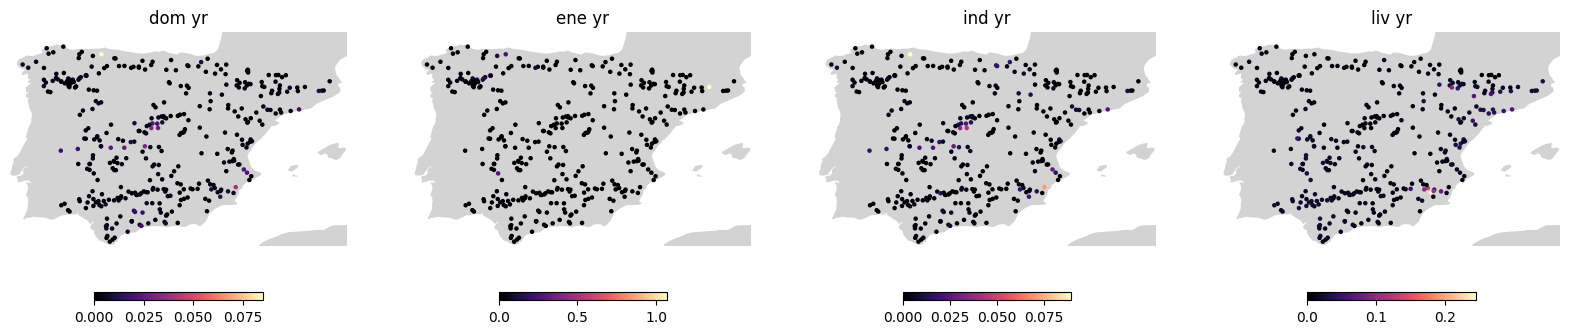

In [11]:
variables = ['dom', 'ene', 'ind', 'liv']

demand = {}
start, end = pd.to_datetime(cfg.start), pd.to_datetime('2023-12-31')
dates = pd.date_range(start, end, freq='D')
for use in tqdm(variables):

    # load data
    ds = read_input_maps(cfg.path_efas / 'maps', variables=[use], crs=cfg.crs)
    ds['time'] = ds['time'] - pd.Timedelta(days=1)
    # compute cachtment statistic
    df = basin_statistics(
        ds, 
        basins, 
        statistic='mean', 
        weight=pixarea
    )[f'{use}_mean'].to_pandas().transpose()

    # convert dataframe to daily resolution
    daily_df = df.reindex(index=dates).ffill()
    daily_df.index.name = 'time'

    # convert to DataArray
    demand[use] = xr.Dataset.from_dataframe(daily_df).to_array(dim='id', name=use)

# combine all demands in one Dataset
demand = xr.Dataset(demand)

# monthly means
demand_m = demand.groupby('time.month').mean('time')

# annual mean
demand_y = demand.groupby('time.year').mean('time').mean('year')
# demand_y = demand.mean('time')

# combine in a single dataset
demand_agg = xr.Dataset()
for key, da in demand_m.items():
    for month in da.month.data:
        demand_agg[f'{key}_{month:02}'] = da.sel(month=month).drop_vars('month')
    demand_agg[f'{key}_yr'] = demand_y[key]

# convert to volume
# demand_agg = demand_agg * 1e-3 * pixarea

# # compute statistics
# attr_demand = basin_statistics(demand_agg, basins, statistic=['sum'], weight=pixarea).to_pandas()

# # rename attributes
# attr_demand.rename(columns={col: '_'.join(col.split('_')[:-1]) for col in attr_demand if 'sum' in col}, inplace=True)

attr_demand = demand_agg.to_pandas()

# plot attributes
plot_attributes(
    attr_demand[['dom_yr', 'ene_yr', 'ind_yr', 'liv_yr']],
    outlets.geometry.x,
    outlets.geometry.y,
    save=path_plots / 'maps_demand.jpg',
    ncols=4,
    extent=extent
)

# save
attributes.append(attr_demand)

### Reservoirs

In [12]:
# # load map or reservoir ID
# var = 'reservoirs'
# res_xr = xr.open_mfdataset(f'{cfg.path_efas}/static_maps/*_{var}_*.nc')['res']
# res_xr = res_xr.sel(extent_dct).compute()

# # extract reservoir ID
# ids = [int(ID) for ID in np.unique(res_xr) if not np.isnan(ID)]
# print('GloFAS represents {0} reservoirs in the study area'.format(len(ids)))

# # load table of total reservoir storage
# storage_pd = pd.read_csv(next((cfg.path_efas / 'tables').glob('rstor*.txt')), sep='\t', header=None, index_col=0).squeeze().astype('int64')
# storage_pd.index.name = 'ResID'
# storage_pd.name = 'storage'

# # create map of reservoir storage
# storage = res_xr.copy(deep=True)
# for ID in ids:
#     storage = storage.where(res_xr != ID, other=storage_pd.loc[ID])
# # storage /= 1e6
# storage.name = 'storage'
# storage.attrs['units'] = 'm3'
# storage.attrs['standard_name'] = 'capacity'
# storage.attrs['long_name'] = 'reservoir_storage_capacity'

# # compute statistics
# attr_reservoir = basin_statistics(
#     storage, 
#     basins, 
#     statistic=['count', 'sum']
# ).to_pandas()

# # rename attributes
# attr_reservoir.rename(columns={'storage_count': 'no_reservoirs', 'storage_sum': 'storage_reservoirs'}, inplace=True)

# # plot attributes
# plot_attributes(
#     attr_reservoir, 
#     outlets.geometry.x, 
#     outlets.geometry.y,
#     save=path_plots / 'maps_reservoir.jpg',
#     extent=extent
# )

# # save
# attributes.append(attr_reservoir)

### Lakes

In [13]:
# # load map or reservoir ID
# var = 'lakes'
# lakes_xr = xr.open_mfdataset(f'{cfg.path_efas}/static_maps/*{var}*.nc')[var]
# lakes_xr = lakes_xr.sel(extent_dct).compute()

# # extract lake ID
# ids = [int(ID) for ID in np.unique(lakes_xr) if not np.isnan(ID)]
# print('GloFAS represents {0} lakes in the study area'.format(len(ids)))

# # load table of lake area
# lakes_pd = pd.read_csv(next((cfg.path_efas / 'tables').glob('lakearea*.txt')), sep='\t', header=None, index_col=0).squeeze().astype('int64')
# lakes_pd.index.name = 'LakeID'
# lakes_pd.name = 'area'

# # create map of lake area
# lakearea = lakes_xr.copy(deep=True)
# for ID in ids:
#     lakearea = lakearea.where(lakes_xr != ID, other=lakes_pd.loc[ID])
# lakearea.name = 'area'
# lakearea.attrs['units'] = 'm2'
# lakearea.attrs['standard_name'] = 'area'
# lakearea.attrs['long_name'] = 'lake_surface_area'

# # compute statistics
# attr_lake = basin_statistics(
#     lakearea, 
#     basins, 
#     statistic=['count', 'sum']
# ).to_pandas()

# # rename attributes
# attr_lake.rename(columns={'area_count': 'no_lakes', 'area_sum': 'area_lakes'}, inplace=True)

# # plot attributes
# plot_attributes(
#     attr_lake, 
#     outlets.geometry.x, 
#     outlets.geometry.y,
#     save=path_plots / 'maps_lake.jpg',
#     extent=extent
# )

# # save
# attributes.append(attr_lake)

### Export

In [14]:
# concatenate all attributes
attrs = pd.concat(attributes, axis=1)
attrs.index.name = outlets.index.name
attrs.sort_index(axis=0, inplace=True)
print('{0} attributes define the characteristics of {1} catchments'.format(*attrs.shape[::-1]))

# export
attrs.to_csv(path_attrs / 'efas_static_maps.csv')

108 attributes define the characteristics of 374 catchments
